### Step 1 - Descriptive, Time-Resolved Plotting
In this tutorial, you'll run a Jupyter notebook to plot the number of clinical and wastewater samples in the dataset over time. The notebook is divided into sections called cells. Run each cell by clicking the ▶ Run button in the toolbar, then proceed to the next cell until you've completed the notebook.

### The Dataset
This dataset pairs SARS-CoV-2 intrahost variant calls from San Diego clinical samples against variant calls from San Diego wastewater samples. Together they let you compare how viral genetic diversity/lineage turnover detected in individual patients tracks with what shows up in community wastewater over the same Sept–Oct 2023 window.

#### Imports

Below, we have a cell containing imports. Python imports are statements that load code from other libraries or files so you can use their functions, classes, and tools in your program. Instead of writing everything from scratch, imports let you reuse existing code. They are typically placed at the beginning of a notebook or script.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the case counts data

In [12]:
cases = pd.read_csv("../data/covid19cases_test.csv")

This cell filters the case counts down to the September-October 2023 window.

In [15]:
cases["date"] = pd.to_datetime(cases["date"])
cases = cases[(cases["date"] >= "2023-09-01") & (cases["date"] <= "2023-10-31")]

This cell makes the plot.

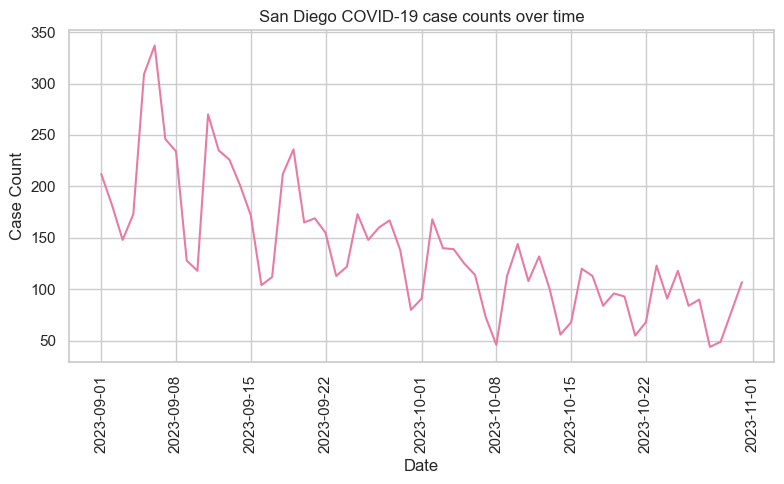

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(x=cases["date"], y=cases["cases"], color="#e87ba4")
plt.xlabel("Date")
plt.ylabel("Case Count")
plt.title("San Diego COVID-19 case counts over time")
plt.xticks(rotation=90)
plt.tight_layout()

#### Data smoothing
Daily SARS-CoV-2 case counts are often influenced by reporting delays, weekends, and holidays, making short-term trends difficult to interpret. Aggregating cases by week smooths out these fluctuations and provides a clearer view. Let's aggregate by week and then replot.

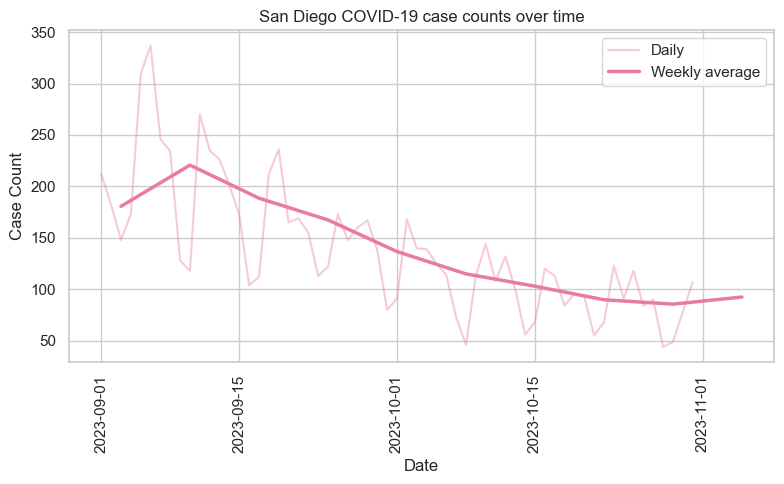

In [19]:
cases_weekly = cases.resample("W", on="date")["cases"].mean().reset_index()

#plot both the daily case counts and the weekly average
plt.figure(figsize=(8, 5))
sns.lineplot(x=cases["date"], y=cases["cases"], color="#e87ba4", alpha=0.4, label="Daily")
sns.lineplot(x=cases_weekly["date"], y=cases_weekly["cases"], color="#e87ba4", linewidth=2.5, label="Weekly average")
plt.xlabel("Date")
plt.ylabel("Case Count")
plt.title("San Diego COVID-19 case counts over time")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

#### Load the sample metadata
First we want to load our clinical and wastewater metadata using the Python package pandas. Run the next cell to load the metadata, which contains sample ids, collection dates, ect. and then print the first five rows to look at it.

In [3]:
clinical_metdata = pd.read_csv("../data/clinical_metadata.csv")
wastewater_metadata = pd.read_csv("../data/wastewater_metadata.csv")
.
print(clinical_metdata.head())
print(wastewater_metadata.head())

     sample_id collection_date   lineage
0  SRR26500334      2023-09-01      GK.4
1  SRR26500335      2023-09-01    GJ.1.2
2  SRR26500336      2023-09-01  FL.1.5.1
3  SRR26500337      2023-09-01      FU.2
4  SRR26500338      2023-09-01    HW.1.1
                                      sample_id collection_date    location
0  10.04.23.ENCOCT02.R2__NA__NA__231006_WW__00X      2023-10-02      Encina
1  10.04.23.ENCSEP27.R2__NA__NA__231006_WW__00X      2023-09-27      Encina
2   10.04.23.PLOCT01.R1__NA__NA__231006_WW__00X      2023-10-01  Point Loma
3   10.04.23.PLOCT02.R1__NA__NA__231006_WW__00X      2023-10-02  Point Loma
4   10.04.23.SBOCT01.R1__NA__NA__231006_WW__00X      2023-10-01   South Bay


#### Plot the number of clinical samples over time
When working with genomic samples it's important to consider how much data is available. Plot the number of clinical samples collected per week to visualize data availability. To do this, we first must count the number of samples collected per week.

In [24]:
clinical_metdata["year_week"] = pd.to_datetime(clinical_metdata["collection_date"]).dt.strftime("%G-W%V")
clinical_counts = clinical_metdata["year_week"].value_counts().sort_index()

This cell makes the plot.

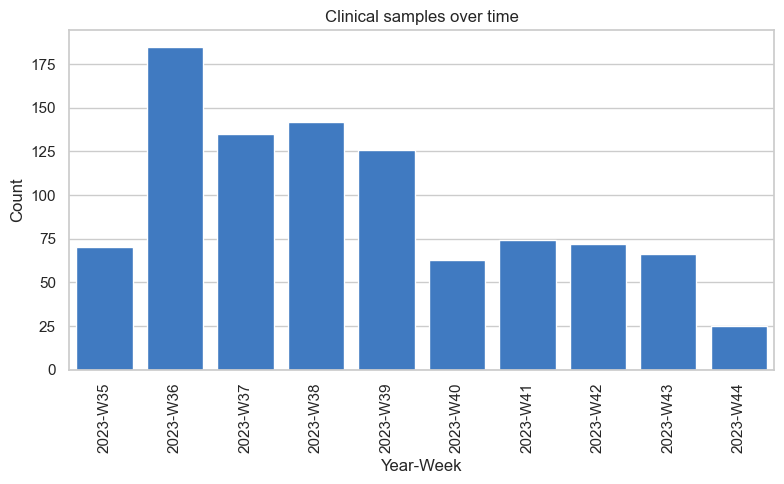

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=clinical_counts.index, y=clinical_counts.values, color="#2a78d6")
plt.xlabel("Year-Week")
plt.ylabel("Count")
plt.title("Clinical samples over time")
plt.xticks(rotation=90)
plt.tight_layout()

#### Plot the number of wastewater samples over time
Repeat the same steps to determine how many wastewater samples we have at each timepoint

In [26]:
wastewater_metadata["year_week"] = pd.to_datetime(wastewater_metadata["collection_date"]).dt.strftime("%G-W%V")
wastewater_counts = wastewater_metadata["year_week"].value_counts().sort_index()

This cell makes the plot.

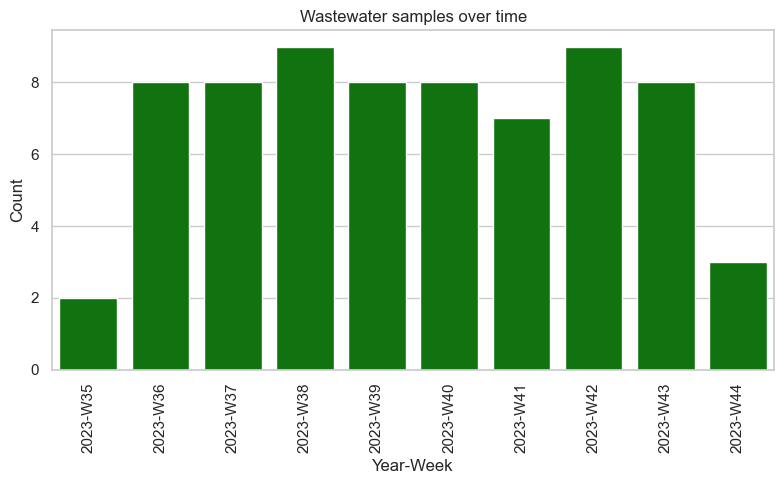

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=wastewater_counts.index, y=wastewater_counts.values, color="#008300")
plt.xlabel("Year-Week")
plt.ylabel("Count")
plt.title("Wastewater samples over time")
plt.xticks(rotation=90)
plt.tight_layout()

Now that we've looked at sample counts for clinical samples and wastewater samples over time, what does the difference appear to be? Why might that be?

#### Comparing sampling counts to case counts
Comparing reported case counts to clinical sequencing counts helps assess how representative the sequenced samples are of the overall epidemic. This context is important because changes in sequencing effort can influence the observed prevalence of variants. Here let's plot clinical sequencing counts and cases counts together.

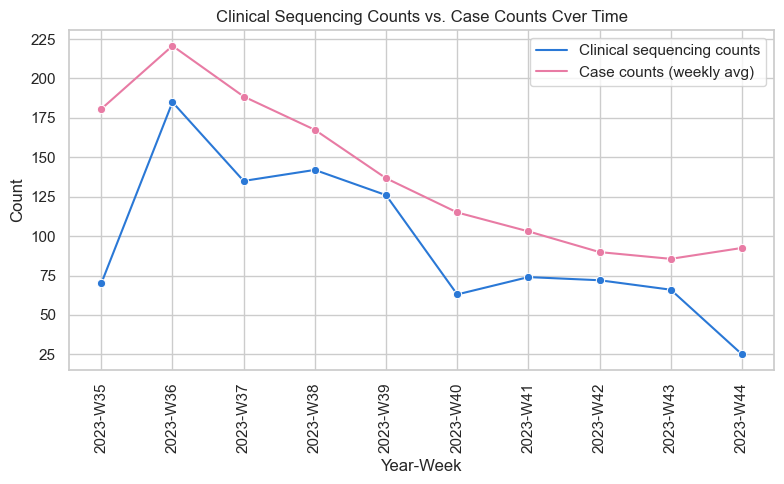

In [30]:
cases["year_week"] = cases["date"].dt.strftime("%G-W%V")
case_week_counts = cases.groupby("year_week")["cases"].mean()

overlay = pd.DataFrame({
    "Clinical sequencing counts": clinical_counts,
    "Case counts (weekly avg)": case_week_counts,
})
overlay.index.name = "year_week"
overlay = overlay.reset_index().melt(id_vars="year_week", var_name="Series", value_name="Count")

plt.figure(figsize=(8, 5))
sns.lineplot(data=overlay, x="year_week", y="Count", hue="Series", palette=["#2a78d6", "#e87ba4"], marker="o")
plt.xlabel("Year-Week")
plt.ylabel("Count")
plt.title("Clinical Sequencing Counts vs. Case Counts Cver Time")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()

How do the trends of clinical sequencing counts and case counts compare?

This is the end of step 1 in the data visualization tutorial. In the next step, we'll look at the spatial resolution of clinical sequences and wastewater sequences over time in San Diego County.